In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
#CONSTANTS
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

### Image Data Preparation and Loading

This stage is responsible for creating data generators that load images from our directory structure, preprocess them by normalizing pixel values (0-1 scale), and organize them into batches.

In [ ]:
#  normalizes pixel values from the standard 0-255 range to values between 0 and 1.

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [6]:
# create data generators for training, validation, and testing

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    'data/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    'data/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


### Build model

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile model

In [9]:
# Compile the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train the model

In [10]:
training_history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.7590 - loss: 0.6071 - val_accuracy: 0.8750 - val_loss: 0.2154
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 312ms/step - accuracy: 0.9465 - loss: 0.1275 - val_accuracy: 0.7500 - val_loss: 0.4323
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 314ms/step - accuracy: 0.9524 - loss: 0.1290 - val_accuracy: 0.8750 - val_loss: 0.2054
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 311ms/step - accuracy: 0.9779 - loss: 0.0673 - val_accuracy: 0.6875 - val_loss: 0.5749
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 317ms/step - accuracy: 0.9805 - loss: 0.0552 - val_accuracy: 0.8125 - val_loss: 0.2678
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 313ms/step - accuracy: 0.9865 - loss: 0.0364 - val_accuracy: 1.0000 - val_loss: 0.0689
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 304ms/step - accuracy: 0.9856 - loss: 0.0370 - val_accuracy: 0.9375 - val_loss: 0.1979
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.9918 - loss: 0

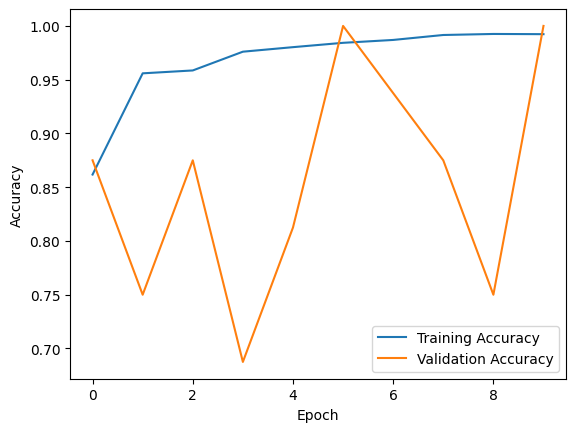

In [11]:
# visualise training history

plt.plot(training_history.history['accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()
